Property Object Detection


In [1]:
#Unzip datasets
import zipfile, os

def unzip(zip_path, extract_to):
  os.makedirs(extract_to, exist_ok=True)
  with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)
  print("✅ unzipped:", zip_path, "-", extract_to)
  print("📁 Top files:", os.listdir(extract_to)[:10])

unzip("/content/satellite_dataset_new.zip", "/content/satellite_dataset_new")
unzip("/content/street_view_dataset_new.zip", "/content/street_view_dataset_new")

✅ unzipped: /content/satellite_dataset_new.zip - /content/satellite_dataset_new
📁 Top files: ['train', 'test', 'val', 'metadata.csv', 'data.yaml']
✅ unzipped: /content/street_view_dataset_new.zip - /content/street_view_dataset_new
📁 Top files: ['train', 'test', 'val', 'metadata.csv', 'data.yaml']


In [2]:
#Install Deep Learning libraries

#install tensorflow
!pip -q install tensorflow

#import libraries
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
#Function 1 - Satellite land-cover classification model training (CNN)

#load dataset
SAT_BASE = "/content/satellite_dataset_new"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

sat_train = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SAT_BASE, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

sat_val = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SAT_BASE, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

sat_test = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SAT_BASE, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

sat_class_names = sat_train.class_names
sat_class_names

Found 1243 files belonging to 3 classes.
Found 265 files belonging to 3 classes.
Found 269 files belonging to 3 classes.


['bare_lands', 'buildings', 'vegetations']

In [4]:
#Improve performance and training speed(prefetch).
#Optimize how data is loaded during model training and evaluation.
#prefetch() = allows data loading and model training to run in parallel.
#AUTOTUNE = Automatically decide the best buffer size based on system resources.
AUTOTUNE = tf.data.AUTOTUNE

sat_train = sat_train.prefetch(buffer_size=AUTOTUNE)
sat_val = sat_val.prefetch(buffer_size=AUTOTUNE)
sta_test = sat_test.prefetch(buffer_size=AUTOTUNE)

In [5]:
#Build the CNN model
def build_cnn(num_classes):
  model = tf.keras.Sequential([
      layers.Rescaling(1./255, input_shape=(128,128,3)),

      layers.Conv2D(32, 3, activation='relu'),
      layers.MaxPooling2D(),

      layers.Conv2D(64, 3, activation='relu'),
      layers.MaxPooling2D(),

      layers.Conv2D(128, 3, activation='relu'),
      layers.MaxPooling2D(),

      layers.Dropout(0.3),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(num_classes, activation='softmax')
  ])
  return model

sat_model = build_cnn(num_classes=len(sat_class_names))
sat_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

sat_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Train the model
#5 epochs
sat_history = sat_model.fit(
    sat_train,
    validation_data=sat_val,
    epochs=5
)

Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.7119 - loss: 0.6290 - val_accuracy: 0.9547 - val_loss: 0.1351
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9245 - loss: 0.1920 - val_accuracy: 0.8604 - val_loss: 0.3105
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9430 - loss: 0.1558 - val_accuracy: 0.9623 - val_loss: 0.0833
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9722 - loss: 0.0759 - val_accuracy: 0.9585 - val_loss: 0.0991
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9472 - loss: 0.1730 - val_accuracy: 0.9509 - val_loss: 0.1761


In [7]:
#Test Accuracy
sat_test_loss, sat_test_acc = sat_model.evaluate(sat_test)
print("✅ Satellite Test Accuracy:", sat_test_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.9789 - loss: 0.0797
✅ Satellite Test Accuracy: 0.9479553699493408


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


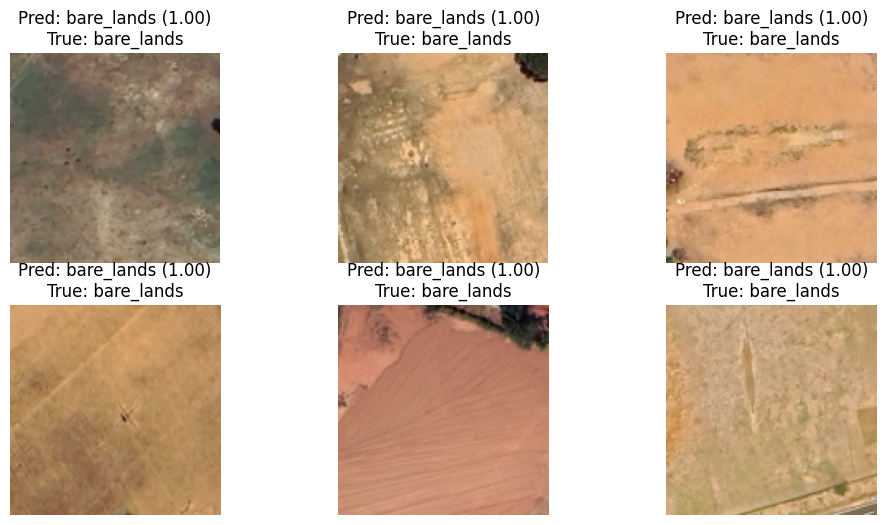

In [8]:
#Predict on a few images
import itertools

def show_predictions(dataset, model, class_names, n=6):
  plt.figure(figsize=(12,6))
  for images, labels in dataset.take(1):
    preds = model.predict(images)
    for i in range(n):
      ax = plt.subplot(2, 3, i+1)
      plt.imshow(images[i].numpy().astype("uint8"))
      pred_class = class_names[np.argmax(preds[i])]
      true_class = class_names[labels[i]]
      conf = float(np.max(preds[i]))
      plt.title(f"Pred: {pred_class} ({conf:.2f})\nTrue: {true_class}")
      plt.axis("off")
  plt.show()

show_predictions(sat_test, sat_model, sat_class_names, n=6)

In [9]:
#Function 2 - Street View property context classification model training

#load dataset
ST_BASE = "/content/street_view_dataset_new"

st_train = tf.keras.utils.image_dataset_from_directory(
    os.path.join(ST_BASE, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

st_val = tf.keras.utils.image_dataset_from_directory(
    os.path.join(ST_BASE, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

st_test = tf.keras.utils.image_dataset_from_directory(
    os.path.join(ST_BASE, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

st_class_names = st_train.class_names
st_class_names

Found 1260 files belonging to 3 classes.
Found 270 files belonging to 3 classes.
Found 270 files belonging to 3 classes.


['boundary_wall_gates', 'building_front', 'vegetation']

In [10]:
#Train the model
st_train = st_train.prefetch(AUTOTUNE)
st_val = st_val.prefetch(AUTOTUNE)
st_test = st_test.prefetch(AUTOTUNE)

st_model = build_cnn(num_classes=len(st_class_names))
st_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

st_history = st_model.fit(
    st_train,
    validation_data=st_val,
    epochs=5
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.4436 - loss: 1.2909 - val_accuracy: 0.7333 - val_loss: 0.5491
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7951 - loss: 0.5392 - val_accuracy: 0.8556 - val_loss: 0.3664
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8531 - loss: 0.3521 - val_accuracy: 0.8963 - val_loss: 0.2611
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9182 - loss: 0.2318 - val_accuracy: 0.9185 - val_loss: 0.2483
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9334 - loss: 0.1801 - val_accuracy: 0.9444 - val_loss: 0.1843


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.9615 - loss: 0.1779
✅ Street View Test Accuracy: 0.9592592716217041
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step


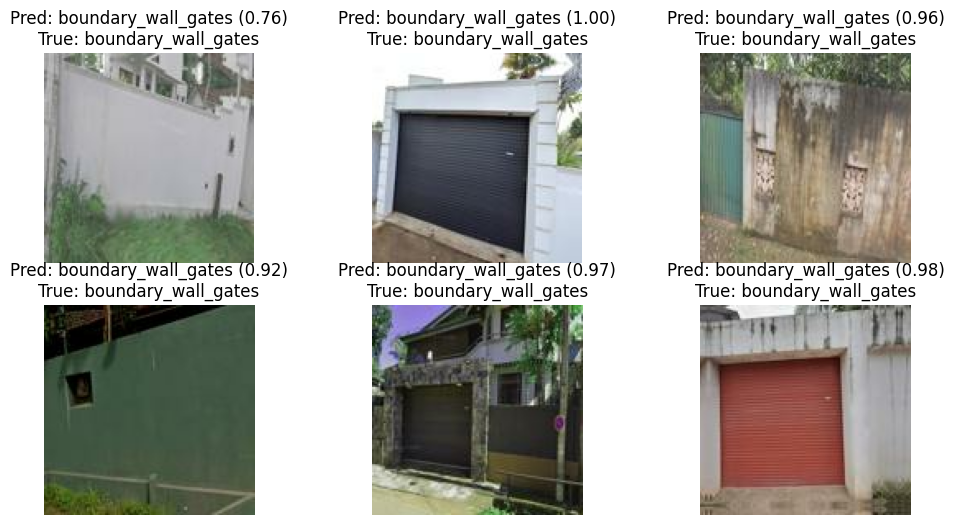

In [11]:
#Evaluation and sample predictions
st_test_loss, st_test_acc = st_model.evaluate(st_test)
print("✅ Street View Test Accuracy:", st_test_acc)

show_predictions(st_test, st_model, st_class_names, n=6)

In [12]:
#A simple rating valuation calculation
#This is not the full municipal formula, I do only a demo.
#Here I used factors for only for demo purposes.
#Idea is,
  #buildings - higher rate
  #bare lands - medium rate
  #vegetation - lower rate
  #boundary wall gates - higher rate
#Here I used model prediction to select a rate factor and compute a valuation score

#Simple valuation rule(demo only)
SAT_VALUATION_FACTOR = {
    "buildings": 1.8,
    "bare_lands": 1.0,
    "vegetations": 0.7
}

ST_VALUATION_FACTOR = {
    "building_front": 1.6,
    "boundary_wall_gates": 1.2,
    "vegetation": 0.7
}

def estimate_value(area_sq_m, predicted_class, factor_map, base_rate=1000):
  """
  Demo valuation: Annual Value Score = base_rate * area * factor
  (Not official CMC factor or formula: Only for my research prototype)
  """
  factor = factor_map.get(predicted_class, 1.0)
  return base_rate * area_sq_m * factor


In [13]:
#Run demo valuation on one predicted image
def predict_one_image(dataset, model, class_names):
  for images, labels in dataset.take(1):
    preds = model.predict(images)
    i = 0
    pred_class = class_names[np.argmax(preds[i])]
    conf = float(np.max(preds[i]))
    return pred_class, conf

#Assuming land area = 450m² (user input for now)
land_area = 450

sat_pred_class, sat_conf = predict_one_image(sat_test, sat_model, sat_class_names)
sat_value = estimate_value(land_area, sat_pred_class, SAT_VALUATION_FACTOR, base_rate=1200)

print("Satellite predicted:", sat_pred_class, "conf:", round(sat_conf,2))
print("✅ Estimated Value Score:", round(sat_value,2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
Satellite predicted: bare_lands conf: 1.0
✅ Estimated Value Score: 540000.0
